# Slingshot Studios Analyst Intern Project
## Mobile Game Player Lifecycle, Engagement & Monetization Analytics

**Business case**

A live-service mobile game team needs to understand which players build an early habit, which players monetize, which players come back, and which players are most likely to disappear after onboarding.

This project treats the SQLite database as a simplified production analytics warehouse and answers four product questions:

1. **Retention:** How well do new players return after install?
2. **Engagement & monetization:** What player behaviors are associated with revenue?
3. **Segmentation:** Can we identify actionable player archetypes from early behavior?
4. **Churn risk:** Can early-session behavior predict whether a player will return after the first two weeks?

**Analytical approach**

- Keep SQL intentionally light: use SQL only to extract clean, analyst-ready tables.
- Do feature engineering, statistics, visualization and modeling in Python.
- Use interpretable definitions and explicitly call out assumptions and limitations.
- End with product actions a game team could test or monitor.

**Skills demonstrated:** SQL joins/aggregation/CTEs • Python/pandas • descriptive statistics • cohorts • retention • monetization • K-Means clustering • logistic regression • random forest • model evaluation • anomaly detection • analytical communication.

In [13]:
# Core imports and display settings
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

DB_PATH = Path(
    r"C:\Users\Shreshth Garg\OneDrive\Desktop\slingshot-player-lifecycle-analytics\csv\data\sample(1).sqlite"
)

assert DB_PATH.exists(), f"SQLite file not found: {DB_PATH}"

con = sqlite3.connect(DB_PATH)

print(f"Database: {DB_PATH}")

Database: C:\Users\Shreshth Garg\OneDrive\Desktop\slingshot-player-lifecycle-analytics\csv\data\sample(1).sqlite


## 1. Data audit: what is available?

The database contains three useful tables:

- `account`: player-level attributes such as signup time, platform and country.
- `account_date_session`: daily player activity, session count and total session duration.
- `iap_purchase`: in-app purchases with USD price and timestamp.

We will verify the schema first, then perform only two SQL extractions.

In [14]:
tables = pd.read_sql("""
SELECT name, type
FROM sqlite_master
WHERE type IN ('table', 'view')
ORDER BY name
""", con)

display(tables)

for table in tables["name"]:
    print(f"\n--- {table} ---")
    display(pd.read_sql(f"PRAGMA table_info({table})", con))

,name,type
0,account,table
1,account_date_session,table
2,iap_purchase,table



--- account ---


,cid,name,type,notnull,dflt_value,pk
0,0,account_id,TEXT,0,None,0
1,1,created_time,timestamp,0,None,0
2,2,created_device,TEXT,0,None,0
3,3,created_platform,TEXT,0,None,0
4,4,country_code,TEXT,0,None,0
5,5,created_app_store_id,INT,0,None,0



--- account_date_session ---


,cid,name,type,notnull,dflt_value,pk
0,0,account_id,TEXT,0,None,0
1,1,date,date,0,None,0
2,2,session_count,INT,0,None,0
3,3,session_duration_sec,INT,0,None,0



--- iap_purchase ---


,cid,name,type,notnull,dflt_value,pk
0,0,account_id,TEXT,0,None,0
1,1,created_time,timestamp,0,None,0
2,2,package_id_hash,TEXT,0,None,0
3,3,iap_price_usd_cents,INT,0,None,0
4,4,app_store_id,INT,0,None,0


In [15]:
volume_sql = """
SELECT 'account' AS table_name, COUNT(*) AS rows, COUNT(DISTINCT account_id) AS players
FROM account
UNION ALL
SELECT 'account_date_session', COUNT(*), COUNT(DISTINCT account_id)
FROM account_date_session
UNION ALL
SELECT 'iap_purchase', COUNT(*), COUNT(DISTINCT account_id)
FROM iap_purchase
"""
display(pd.read_sql(volume_sql, con))

,table_name,rows,players
0,account,112792,112792
1,account_date_session,1698974,112451
2,iap_purchase,9909,1549


## 2. Minimal SQL extraction

**SQL is deliberately limited to extraction and one clean join.**

The second query uses one CTE to aggregate purchases to the same player-day grain as session data, then left-joins it. This avoids duplicating a player's daily revenue when there are multiple purchase rows on the same day.

After this step, the rest of the project is Python.

In [16]:
SQL_ACCOUNTS = """
SELECT
    account_id,
    created_time,
    created_device,
    created_platform,
    country_code,
    created_app_store_id
FROM account
"""

accounts = pd.read_sql(SQL_ACCOUNTS, con, parse_dates=["created_time"])
accounts["created_date"] = accounts["created_time"].dt.normalize()
accounts.head()

,account_id,created_time,created_device,created_platform,country_code,created_app_store_id,created_date
0,13514010,2016-03-02 17:11:00.332,"iPhone6,2",iOS,GB,1,2016-03-02
1,4308483975,2016-03-02 20:57:46.140,MIDC147PJ,Android,FR,2,2016-03-02
2,17193137415,2016-03-02 13:52:16.735,SM-G360F,Android,IT,2,2016-03-02
3,21488104920,2016-03-02 12:43:27.899,H60-L01,Android,CN,8,2016-03-02
4,21488107995,2016-03-02 17:20:12.145,GT-I9500,Android,RU,2,2016-03-02


In [17]:
SQL_DAILY_ACTIVITY = """
WITH daily_purchase AS (
    SELECT
        account_id,
        DATE(created_time) AS date,
        COUNT(*) AS purchases,
        SUM(iap_price_usd_cents) / 100.0 AS revenue_usd
    FROM iap_purchase
    GROUP BY account_id, DATE(created_time)
)
SELECT
    s.account_id,
    s.date,
    s.session_count,
    s.session_duration_sec,
    COALESCE(p.purchases, 0) AS purchases,
    COALESCE(p.revenue_usd, 0.0) AS revenue_usd
FROM account_date_session AS s
LEFT JOIN daily_purchase AS p
    ON s.account_id = p.account_id
   AND s.date = p.date
"""

activity = pd.read_sql(SQL_DAILY_ACTIVITY, con, parse_dates=["date"])
print("Accounts:", accounts.shape)
print("Daily activity:", activity.shape)
display(activity.head())

Accounts: (112792, 7)
Daily activity: (1698974, 6)


,account_id,date,session_count,session_duration_sec,purchases,revenue_usd
0,68730811144,2016-01-01,1,47,0,0.000
1,68730812806,2016-01-01,1,204,0,0.000
2,68730829426,2016-01-01,12,4703,0,0.000
3,68730829426,2016-01-02,9,4676,0,0.000
4,68730829426,2016-01-03,9,2271,0,0.000


## 3. Data quality checks

A good analyst should validate the basic assumptions before interpreting trends.

In [18]:
quality = {
    "unique_account_ids": accounts["account_id"].nunique(),
    "account_rows": len(accounts),
    "activity_rows": len(activity),
    "activity_player_ids": activity["account_id"].nunique(),
    "duplicate_player_days": activity.duplicated(["account_id", "date"]).sum(),
    "negative_session_counts": (activity["session_count"] < 0).sum(),
    "negative_durations": (activity["session_duration_sec"] < 0).sum(),
    "negative_revenue": (activity["revenue_usd"] < 0).sum(),
    "missing_account_platform": accounts["created_platform"].isna().sum(),
    "missing_country": accounts["country_code"].isna().sum(),
}
display(pd.Series(quality, name="value").to_frame())

print("Activity date range:", activity["date"].min().date(), "to", activity["date"].max().date())
print("Account signup date range:", accounts["created_date"].min().date(), "to", accounts["created_date"].max().date())

,value
unique_account_ids,112792
account_rows,112792
activity_rows,1698974
activity_player_ids,112451
duplicate_player_days,0
negative_session_counts,0
negative_durations,0
negative_revenue,0
missing_account_platform,0
missing_country,107


Activity date range: 2016-01-01 to 2016-12-31
Account signup date range: 2016-01-01 to 2016-12-31


In [19]:
activity = activity.merge(
    accounts[["account_id", "created_date", "created_platform", "country_code"]],
    on="account_id",
    how="left",
    validate="many_to_one"
)
activity["day_number"] = (activity["date"] - activity["created_date"]).dt.days
activity["active"] = (activity["session_count"] > 0).astype(int)

print("Day-number range:", activity["day_number"].min(), "to", activity["day_number"].max())
display(activity.head())

Day-number range: 0.0 to 365.0


,account_id,date,session_count,session_duration_sec,purchases,revenue_usd,created_date,created_platform,country_code,day_number,active
0,68730811144,2016-01-01,1,47,0,0.000,2016-01-01,Android,US,0.000,1
1,68730812806,2016-01-01,1,204,0,0.000,2016-01-01,Android,US,0.000,1
2,68730829426,2016-01-01,12,4703,0,0.000,2016-01-01,Android,CO,0.000,1
3,68730829426,2016-01-02,9,4676,0,0.000,2016-01-01,Android,CO,1.000,1
4,68730829426,2016-01-03,9,2271,0,0.000,2016-01-01,Android,CO,2.000,1


## 4. KPI baseline

For a mobile game analyst, the first dashboard-level metrics should establish D1/D7/D30 retention, payer conversion, revenue, ARPPU, sessions and play time.

Retention uses a strict exact-day definition: D7 means the player had activity exactly 7 days after signup.

In [20]:
def exact_day_retention(activity_df, accounts_df, day):
    latest_observable = activity_df["date"].max()
    eligible = accounts_df["created_date"] <= (latest_observable - pd.Timedelta(days=day))
    numerator = activity_df.loc[activity_df["day_number"].eq(day), "account_id"].nunique()
    denominator = int(eligible.sum())
    return numerator, denominator, numerator / denominator if denominator else np.nan

retention_rows = []
for day in [1, 7, 30]:
    num, den, rate = exact_day_retention(activity, accounts, day)
    retention_rows.append({
        "metric": f"D{day} retention",
        "returning_players": num,
        "eligible_players": den,
        "rate": rate
    })

retention_df = pd.DataFrame(retention_rows)
retention_df["rate_pct"] = retention_df["rate"] * 100

payer_rate = (activity.groupby("account_id")["purchases"].sum() > 0).mean()
total_revenue = activity["revenue_usd"].sum()
payers = activity.loc[activity["purchases"] > 0, "account_id"].nunique()
arppu = total_revenue / payers if payers else np.nan

display(retention_df[["metric", "returning_players", "eligible_players", "rate_pct"]])
print(f"Lifetime observed payer conversion: {payer_rate:.2%}")
print(f"Observed IAP revenue: ${total_revenue:,.2f}")
print(f"Observed payers: {payers:,}")
print(f"ARPPU: ${arppu:,.2f}")

,metric,returning_players,eligible_players,rate_pct
0,D1 retention,44513,112368,39.614
1,D7 retention,22177,110948,19.989
2,D30 retention,11227,106228,10.569


Lifetime observed payer conversion: 1.38%
Observed IAP revenue: $42,494.66
Observed payers: 1,548
ARPPU: $27.45


## 5. Cohort retention

We build signup-month cohorts and measure exact-day D1/D7/D30 retention, restricting denominators so each cohort has enough observation time.

In [21]:
accounts["signup_month"] = accounts["created_date"].dt.to_period("M").astype(str)
cohort_base = accounts[["account_id", "signup_month", "created_date"]].copy()

cohort_retention = []
for day in [1, 7, 30]:
    eligible = cohort_base[
        cohort_base["created_date"] <= activity["date"].max() - pd.Timedelta(days=day)
    ]
    active_ids = set(activity.loc[activity["day_number"].eq(day), "account_id"])
    tmp = eligible.assign(returned=eligible["account_id"].isin(active_ids))
    out = tmp.groupby("signup_month").agg(
        eligible_players=("account_id", "size"),
        retained_players=("returned", "sum"),
    )
    out["retention_rate"] = out["retained_players"] / out["eligible_players"]
    out["day"] = day
    cohort_retention.append(out.reset_index())

cohort_retention = pd.concat(cohort_retention, ignore_index=True)
pivot = cohort_retention.pivot(index="signup_month", columns="day", values="retention_rate")
pivot = pivot.rename(columns={1: "D1", 7: "D7", 30: "D30"})

display((pivot * 100).round(1))

day,D1,D7,D30
signup_month,,,
2016-01,42.600,23.300,13.300
2016-02,40.400,20.000,10.100
2016-03,37.500,19.600,10.900
2016-04,37.800,19.300,10.900
2016-05,38.600,20.100,10.000
2016-06,37.400,18.000,9.900
2016-07,40.700,19.100,9.400
2016-08,40.500,18.100,8.100
2016-09,38.300,18.500,9.600


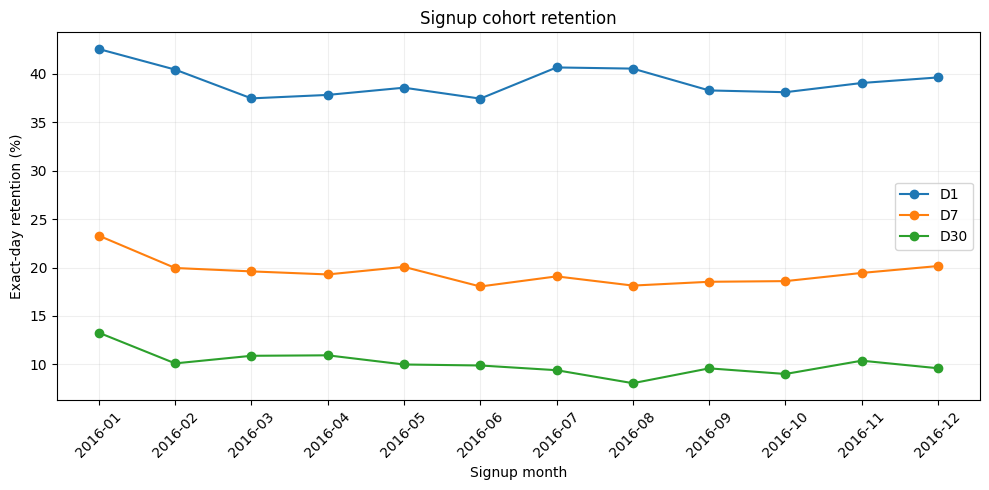

In [22]:
plt.figure(figsize=(10, 5))
for col in [c for c in ["D1", "D7", "D30"] if c in pivot.columns]:
    plt.plot(pivot.index, pivot[col] * 100, marker="o", label=col)
plt.title("Signup cohort retention")
plt.xlabel("Signup month")
plt.ylabel("Exact-day retention (%)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 6. Player-level feature table

We separate **early behavior features (days 0–13)** from the future outcome. This is the critical design choice that prevents obvious look-ahead leakage in the churn model.

In [23]:
lifetime = activity.groupby("account_id").agg(
    lifetime_active_days=("date", "nunique"),
    lifetime_sessions=("session_count", "sum"),
    lifetime_seconds=("session_duration_sec", "sum"),
    lifetime_purchases=("purchases", "sum"),
    lifetime_revenue=("revenue_usd", "sum"),
).reset_index()

early14 = (
    activity.loc[activity["day_number"].between(0, 13)]
    .groupby("account_id")
    .agg(
        active_days_14=("date", "nunique"),
        sessions_14=("session_count", "sum"),
        seconds_14=("session_duration_sec", "sum"),
        purchases_14=("purchases", "sum"),
        revenue_14=("revenue_usd", "sum"),
    )
    .reset_index()
)

features = (
    accounts[["account_id", "created_platform", "country_code", "created_date", "signup_month"]]
    .merge(lifetime, on="account_id", how="left")
    .merge(early14, on="account_id", how="left")
)

numeric_fill = [
    "lifetime_active_days", "lifetime_sessions", "lifetime_seconds",
    "lifetime_purchases", "lifetime_revenue", "active_days_14",
    "sessions_14", "seconds_14", "purchases_14", "revenue_14"
]
features[numeric_fill] = features[numeric_fill].fillna(0)
features["hours_14"] = features["seconds_14"] / 3600
features["avg_session_sec_14"] = np.where(
    features["sessions_14"] > 0,
    features["seconds_14"] / features["sessions_14"],
    0
)
features["payer_14"] = (features["purchases_14"] > 0).astype(int)

display(features.head())

,account_id,created_platform,country_code,created_date,signup_month,lifetime_active_days,lifetime_sessions,lifetime_seconds,lifetime_purchases,lifetime_revenue,active_days_14,sessions_14,seconds_14,purchases_14,revenue_14,hours_14,avg_session_sec_14,payer_14
0,13514010,iOS,GB,2016-03-02,2016-03,15.000,72.000,"25,681.000",1.000,1.840,13.000,68.000,"23,917.000",1.000,1.840,6.644,351.721,1
1,4308483975,Android,FR,2016-03-02,2016-03,2.000,2.000,453.000,0.000,0.000,2.000,2.000,453.000,0.000,0.000,0.126,226.500,0
2,17193137415,Android,IT,2016-03-02,2016-03,24.000,35.000,"6,478.000",0.000,0.000,1.000,1.000,169.000,0.000,0.000,0.047,169.000,0
3,21488104920,Android,CN,2016-03-02,2016-03,10.000,28.000,"11,533.000",0.000,0.000,10.000,28.000,"11,533.000",0.000,0.000,3.204,411.893,0
4,21488107995,Android,RU,2016-03-02,2016-03,1.000,1.000,42.000,0.000,0.000,1.000,1.000,42.000,0.000,0.000,0.012,42.000,0


## 7. Engagement and monetization

The deeper product question is whether early engagement intensity separates payers from non-payers.

In [24]:
payer_summary = features.assign(
    payer=features["lifetime_purchases"] > 0
).groupby("payer").agg(
    players=("account_id", "size"),
    median_active_days_14=("active_days_14", "median"),
    median_sessions_14=("sessions_14", "median"),
    median_hours_14=("hours_14", "median"),
    avg_revenue=("lifetime_revenue", "mean"),
    median_revenue=("lifetime_revenue", "median"),
).reset_index()

payer_summary["payer"] = payer_summary["payer"].map({True: "Payer", False: "Non-payer"})
display(payer_summary)

platform_summary = features.groupby("created_platform").agg(
    players=("account_id", "size"),
    payers=("lifetime_purchases", lambda x: (x > 0).sum()),
    revenue=("lifetime_revenue", "sum"),
    avg_revenue_per_player=("lifetime_revenue", "mean"),
).reset_index()
platform_summary["payer_conversion"] = platform_summary["payers"] / platform_summary["players"]

display(platform_summary.sort_values("revenue", ascending=False))

,payer,players,median_active_days_14,median_sessions_14,median_hours_14,avg_revenue,median_revenue
0,Non-payer,111244,1.000,2.000,0.218,0.000,0.000
1,Payer,1548,14.000,62.000,7.552,27.451,3.680


,created_platform,players,payers,revenue,avg_revenue_per_player,payer_conversion
0,Android,92253,1151,"25,166.590",0.273,0.012
1,iOS,20539,397,"17,328.070",0.844,0.019


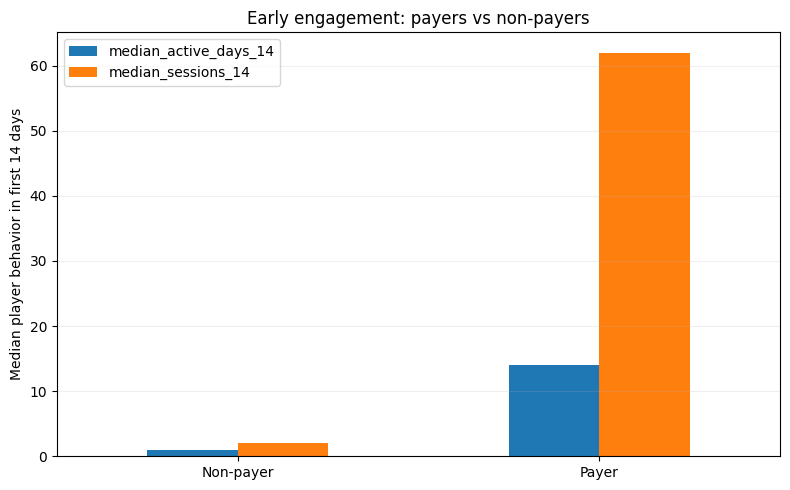

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))
payer_plot = payer_summary.set_index("payer")[["median_active_days_14", "median_sessions_14"]]
payer_plot.plot(kind="bar", ax=ax)
ax.set_title("Early engagement: payers vs non-payers")
ax.set_ylabel("Median player behavior in first 14 days")
ax.set_xlabel("")
ax.grid(axis="y", alpha=0.2)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Player segmentation with K-Means

We cluster players with at least one active day using log-transformed early behavior because the raw distributions are highly skewed.

Features: active days, sessions, hours, purchases and revenue in days 0–13.

In [26]:
segment_cols = ["active_days_14", "sessions_14", "hours_14", "purchases_14", "revenue_14"]

seg_df = features.loc[features["active_days_14"] > 0].copy()
X_seg = np.log1p(seg_df[segment_cols])
X_seg_scaled = StandardScaler().fit_transform(X_seg)

kmeans = KMeans(n_clusters=4, n_init=20, random_state=42)
seg_df["cluster"] = kmeans.fit_predict(X_seg_scaled)

segment_summary = seg_df.groupby("cluster").agg(
    players=("account_id", "size"),
    active_days_14=("active_days_14", "median"),
    sessions_14=("sessions_14", "median"),
    hours_14=("hours_14", "median"),
    purchases_14=("purchases_14", "median"),
    revenue_14=("revenue_14", "median"),
    payer_14_rate=("payer_14", "mean"),
).reset_index()

display(segment_summary.sort_values("players", ascending=False))

,cluster,players,active_days_14,sessions_14,hours_14,purchases_14,revenue_14,payer_14_rate
1,1,69229,1.000,1.000,0.042,0.000,0.000,0.000
3,3,24387,4.000,9.000,1.165,0.000,0.000,0.003
0,0,18118,13.000,47.000,5.469,0.000,0.000,0.019
2,2,576,14.000,73.500,9.887,3.000,7.375,1.000


In [27]:
def label_cluster(row):
    if row["revenue_14"] > 5 or row["purchases_14"] >= 2:
        return "Engaged payers"
    if row["active_days_14"] >= 8 and row["sessions_14"] >= 25:
        return "Highly engaged non-payers"
    if row["active_days_14"] <= 2:
        return "One-and-done / low habit"
    return "Casual returners"

label_map = segment_summary.set_index("cluster").apply(label_cluster, axis=1).to_dict()
seg_df["segment"] = seg_df["cluster"].map(label_map)
segment_summary["segment"] = segment_summary["cluster"].map(label_map)

segment_summary = segment_summary[
    ["cluster", "segment", "players", "active_days_14", "sessions_14",
     "hours_14", "purchases_14", "revenue_14", "payer_14_rate"]
].sort_values("players", ascending=False)

display(segment_summary)

,cluster,segment,players,active_days_14,sessions_14,hours_14,purchases_14,revenue_14,payer_14_rate
1,1,One-and-done / low habit,69229,1.000,1.000,0.042,0.000,0.000,0.000
3,3,Casual returners,24387,4.000,9.000,1.165,0.000,0.000,0.003
0,0,Highly engaged non-payers,18118,13.000,47.000,5.469,0.000,0.000,0.019
2,2,Engaged payers,576,14.000,73.500,9.887,3.000,7.375,1.000


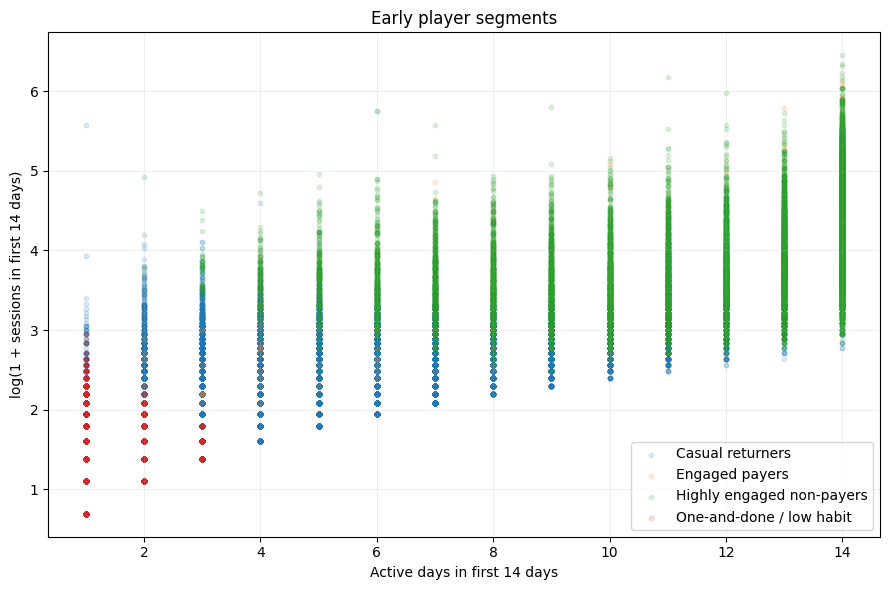

In [28]:
plt.figure(figsize=(9, 6))
for segment_name, grp in seg_df.groupby("segment"):
    plt.scatter(
        grp["active_days_14"],
        np.log1p(grp["sessions_14"]),
        s=10,
        alpha=0.15,
        label=segment_name
    )
plt.title("Early player segments")
plt.xlabel("Active days in first 14 days")
plt.ylabel("log(1 + sessions in first 14 days)")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Segment action framework

- **One-and-done / low habit:** improve first-session experience, early goals and return triggers.
- **Casual returners:** reinforce a repeat weekly habit through content cadence and reminders.
- **Highly engaged non-payers:** test value communication and non-intrusive monetization opportunities.
- **Engaged payers:** protect experience, personalize offers and monitor revenue concentration.

These are hypotheses for product action, not causal conclusions.

## 8A. Monetization deep dive

This section expands monetization into the core live-service metrics: total revenue, payer conversion, ARPU, ARPPU, transaction frequency, and revenue by player segment.

**Metric definitions**
- **Revenue:** total observed IAP revenue in USD.
- **Payer conversion:** unique payers / total players.
- **ARPU:** revenue / total players.
- **ARPPU:** revenue / unique payers.
- **Transaction frequency:** purchase transactions / unique payers.

These are descriptive metrics; they do not imply causal effects.


In [29]:
total_players = features["account_id"].nunique()
total_revenue = features["lifetime_revenue"].sum()
payer_count = int((features["lifetime_purchases"] > 0).sum())
payer_conversion = payer_count / total_players if total_players else 0
arpu = total_revenue / total_players if total_players else 0
arppu = total_revenue / payer_count if payer_count else 0
total_transactions = features["lifetime_purchases"].sum()
transaction_frequency = total_transactions / payer_count if payer_count else 0

monetization_kpis = pd.DataFrame({
    "metric": ["Players", "Revenue", "Payers", "Payer conversion", "ARPU", "ARPPU", "Transactions", "Transactions per payer"],
    "value": [total_players, total_revenue, payer_count, payer_conversion, arpu, arppu, total_transactions, transaction_frequency],
})
display(monetization_kpis)


,metric,value
0,Players,"112,792.000"
1,Revenue,"42,494.660"
2,Payers,"1,548.000"
3,Payer conversion,0.014
4,ARPU,0.377
5,ARPPU,27.451
6,Transactions,"9,900.000"
7,Transactions per payer,6.395


In [30]:
segment_monetization = seg_df.groupby("segment").agg(
    players=("account_id", "size"),
    payers=("lifetime_purchases", lambda s: (s > 0).sum()),
    revenue_usd=("lifetime_revenue", "sum"),
    transactions=("lifetime_purchases", "sum"),
    avg_revenue_per_player=("lifetime_revenue", "mean"),
    median_revenue_per_player=("lifetime_revenue", "median"),
).reset_index()
segment_monetization["payer_conversion"] = segment_monetization["payers"] / segment_monetization["players"]
segment_monetization["arpu"] = segment_monetization["revenue_usd"] / segment_monetization["players"]
segment_monetization["arppu"] = np.where(segment_monetization["payers"] > 0, segment_monetization["revenue_usd"] / segment_monetization["payers"], 0)
segment_monetization["transactions_per_payer"] = np.where(segment_monetization["payers"] > 0, segment_monetization["transactions"] / segment_monetization["payers"], 0)
segment_monetization["revenue_share"] = np.where(total_revenue > 0, segment_monetization["revenue_usd"] / total_revenue, 0)
display(segment_monetization.sort_values("revenue_usd", ascending=False))


,segment,players,payers,revenue_usd,transactions,avg_revenue_per_player,median_revenue_per_player,payer_conversion,arpu,arppu,transactions_per_payer,revenue_share
1,Engaged payers,576,576,"33,311.600","6,536.000",57.833,12.885,1.000,57.833,57.833,11.347,0.784
2,Highly engaged non-payers,18118,737,"6,487.450","2,455.000",0.358,0.000,0.041,0.358,8.803,3.331,0.153
0,Casual returners,24387,159,"1,691.770",653.000,0.069,0.000,0.007,0.069,10.640,4.107,0.040
3,One-and-done / low habit,69229,73,672.420,209.000,0.010,0.000,0.001,0.010,9.211,2.863,0.016


In [31]:
payer_distribution = features.loc[features["lifetime_purchases"] > 0, ["account_id", "lifetime_purchases", "lifetime_revenue", "lifetime_active_days", "lifetime_sessions"]].copy()
payer_distribution["avg_transaction_value"] = payer_distribution["lifetime_revenue"] / payer_distribution["lifetime_purchases"]
payer_behavior = payer_distribution.assign(
    transaction_band=pd.cut(
        payer_distribution["lifetime_purchases"],
        bins=[0, 1, 3, 10, np.inf],
        labels=["1 transaction", "2–3", "4–10", "11+"],
        include_lowest=True,
    )
).groupby("transaction_band", observed=False).agg(
    payers=("account_id", "size"),
    revenue_usd=("lifetime_revenue", "sum"),
    avg_revenue=("lifetime_revenue", "mean"),
    median_revenue=("lifetime_revenue", "median"),
    avg_active_days=("lifetime_active_days", "mean"),
    avg_sessions=("lifetime_sessions", "mean"),
).reset_index()
payer_behavior["revenue_share"] = payer_behavior["revenue_usd"] / total_revenue if total_revenue else 0
display(payer_behavior)


,transaction_band,payers,revenue_usd,avg_revenue,median_revenue,avg_active_days,avg_sessions,revenue_share
0,1 transaction,562,977.100,1.739,1.100,82.900,401.114,0.023
1,2–3,402,"2,327.850",5.791,3.680,96.224,476.037,0.055
2,4–10,341,"7,037.250",20.637,11.060,123.575,624.924,0.166
3,11+,243,"32,152.460",132.315,51.560,177.276,"1,107.288",0.757


## 8B. Performance & player behavior

Players are grouped into **low**, **medium**, and **high engagement** tiers using first-14-day activity. We compare spending behavior and quantify the association between activity and spending. The percentile thresholds are descriptive and intended for player comparison, not as universal design cutoffs.


In [32]:
behavior = features.copy()
behavior["engagement_score"] = (
    np.log1p(behavior["active_days_14"])
    + np.log1p(behavior["sessions_14"])
    + np.log1p(behavior["hours_14"])
)
q_low, q_high = behavior["engagement_score"].quantile([0.40, 0.80])
behavior["engagement_tier"] = pd.cut(behavior["engagement_score"], bins=[-np.inf, q_low, q_high, np.inf], labels=["Low engagement", "Medium engagement", "High engagement"])


In [33]:
engagement_summary = behavior.groupby("engagement_tier", observed=False).agg(
    players=("account_id", "size"),
    avg_active_days_14=("active_days_14", "mean"),
    avg_sessions_14=("sessions_14", "mean"),
    avg_hours_14=("hours_14", "mean"),
    payer_conversion=("payer_14", "mean"),
    revenue_usd=("lifetime_revenue", "sum"),
    arpu=("lifetime_revenue", "mean"),
    median_revenue=("lifetime_revenue", "median"),
).reset_index()
engagement_summary["revenue_share"] = np.where(total_revenue > 0, engagement_summary["revenue_usd"] / total_revenue, 0)
display(engagement_summary)


,engagement_tier,players,avg_active_days_14,avg_sessions_14,avg_hours_14,payer_conversion,revenue_usd,arpu,median_revenue,revenue_share
0,Low engagement,45118,0.989,0.989,0.038,0.000,621.920,0.014,0.000,0.015
1,Medium engagement,45115,2.776,5.560,0.684,0.003,"2,370.420",0.053,0.000,0.056
2,High engagement,22559,11.287,55.464,6.445,0.039,"39,502.320",1.751,0.000,0.930


,lifetime_revenue,revenue_14,lifetime_purchases
active_days_14,0.055,0.063,0.109
sessions_14,0.087,0.083,0.163
hours_14,0.121,0.119,0.204
avg_session_sec_14,0.028,0.035,0.039


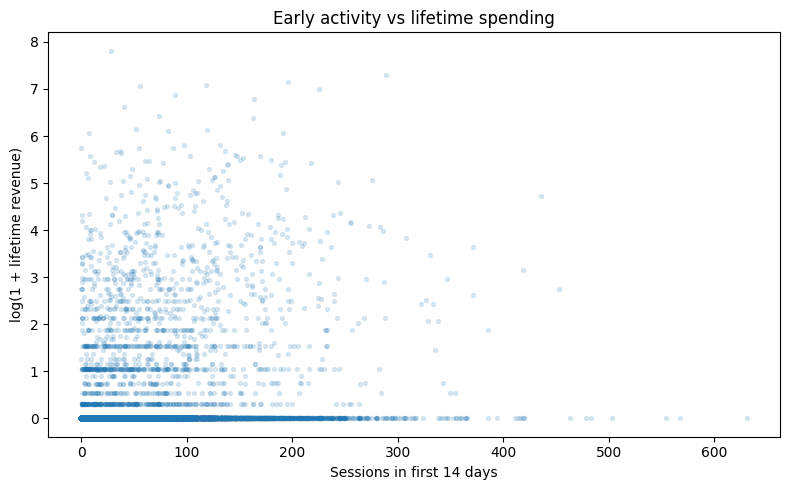

In [34]:
correlation_cols = ["active_days_14", "sessions_14", "hours_14", "avg_session_sec_14", "purchases_14", "revenue_14", "lifetime_purchases", "lifetime_revenue"]
corr = behavior[correlation_cols].corr(method="pearson").round(3)
activity_spending_corr = corr.loc[["active_days_14", "sessions_14", "hours_14", "avg_session_sec_14"], ["lifetime_revenue", "revenue_14", "lifetime_purchases"]]
display(activity_spending_corr)

plt.figure(figsize=(8, 5))
plt.scatter(behavior["sessions_14"], np.log1p(behavior["lifetime_revenue"]), s=8, alpha=0.15)
plt.xlabel("Sessions in first 14 days")
plt.ylabel("log(1 + lifetime revenue)")
plt.title("Early activity vs lifetime spending")
plt.tight_layout()
plt.show()


In [35]:
engagement_segment_view = seg_df.merge(behavior[["account_id", "engagement_tier", "engagement_score"]], on="account_id", how="left")
segment_behavior = engagement_segment_view.groupby("segment").agg(
    players=("account_id", "size"),
    avg_engagement_score=("engagement_score", "mean"),
    avg_active_days_14=("active_days_14", "mean"),
    avg_sessions_14=("sessions_14", "mean"),
    avg_hours_14=("hours_14", "mean"),
    payer_conversion=("lifetime_purchases", lambda s: (s > 0).mean()),
    avg_lifetime_revenue=("lifetime_revenue", "mean"),
    median_lifetime_revenue=("lifetime_revenue", "median"),
).reset_index()
display(segment_behavior.sort_values("avg_lifetime_revenue", ascending=False))


,segment,players,avg_engagement_score,avg_active_days_14,avg_sessions_14,avg_hours_14,payer_conversion,avg_lifetime_revenue,median_lifetime_revenue
1,Engaged payers,576,9.044,11.905,93.151,12.432,1.000,57.833,12.885
2,Highly engaged non-payers,18118,8.431,11.993,61.716,7.139,0.041,0.358,0.000
0,Casual returners,24387,4.837,4.866,10.871,1.326,0.007,0.069,0.000
3,One-and-done / low habit,69229,1.764,1.180,1.585,0.131,0.001,0.010,0.000


### Product interpretation

- **Highly engaged + high spending:** core monetizing players; protect their experience and study the behaviors associated with durable value.
- **Highly engaged + low spending:** strong candidates for value-proposition or offer experiments, without assuming they should be monetized aggressively.
- **Low engagement + spending:** valuable but potentially fragile; improve experience and retention before pushing deeper monetization.
- **Low engagement + low spending:** focus on first-session quality and habit formation.

Correlation is used to prioritize hypotheses, not to claim that activity causes spending.


## 9. Churn-risk model

### Target definition

- **Observation window:** first 14 calendar days (days 0–13).
- **Outcome window:** next 30 days (days 14–43).
- **Retained:** at least one active day in days 14–43.
- **Churned:** no active day in days 14–43.

Only players with enough historical runway for the full outcome window are included.

In [36]:
latest_date = activity["date"].max()
label_cutoff = latest_date - pd.Timedelta(days=43)

eligible_ids = set(
    features.loc[features["created_date"] <= label_cutoff, "account_id"]
)

future_active = (
    activity.loc[activity["day_number"].between(14, 43)]
    .groupby("account_id")
    .size()
    .gt(0)
    .astype(int)
    .rename("retained_30d")
)

model_df = features[features["account_id"].isin(eligible_ids)].copy()
model_df = model_df.merge(future_active, on="account_id", how="left")
model_df["retained_30d"] = model_df["retained_30d"].fillna(0).astype(int)
model_df["churn_30d"] = 1 - model_df["retained_30d"]

print("Eligible players:", len(model_df))
print("Post-onboarding return rate:", model_df["retained_30d"].mean())
print("Churn rate:", model_df["churn_30d"].mean())
display(model_df["churn_30d"].value_counts(normalize=True).rename("share").to_frame())

Eligible players: 103888
Post-onboarding return rate: 0.2499711227475743
Churn rate: 0.7500288772524257


,share
churn_30d,
1,0.750
0,0.250


### Compare an interpretable linear baseline with a non-linear model

The candidate models are:
1. **Logistic regression** — easy to explain to product partners.
2. **Random forest** — captures non-linear interactions.

The test set is held out before fitting.

In [37]:
model_df["country_model"] = model_df["country_code"].where(
    model_df["country_code"].isin(
        model_df["country_code"].value_counts().head(10).index
    ),
    "Other"
)

model_features = [
    "created_platform", "country_model",
    "active_days_14", "sessions_14", "hours_14",
    "avg_session_sec_14", "purchases_14", "revenue_14"
]

X = model_df[model_features]
y = model_df["churn_30d"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

categorical_cols = ["created_platform", "country_model"]
numeric_cols = [c for c in model_features if c not in categorical_cols]

def make_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
            ]), categorical_cols),
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scale", StandardScaler())
            ]), numeric_cols)
        ]
    )

logit = Pipeline([
    ("prep", make_preprocessor()),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

rf = Pipeline([
    ("prep", make_preprocessor()),
    ("model", RandomForestClassifier(
        n_estimators=250,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ))
])

logit.fit(X_train, y_train)
rf.fit(X_train, y_train)

p_logit = logit.predict_proba(X_test)[:, 1]
p_rf = rf.predict_proba(X_test)[:, 1]

model_scores = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "ROC AUC": roc_auc_score(y_test, p_logit),
        "PR AUC": average_precision_score(y_test, p_logit)
    },
    {
        "model": "Random Forest",
        "ROC AUC": roc_auc_score(y_test, p_rf),
        "PR AUC": average_precision_score(y_test, p_rf)
    }
])

display(model_scores)

,model,ROC AUC,PR AUC
0,Logistic Regression,0.924,0.968
1,Random Forest,0.928,0.971


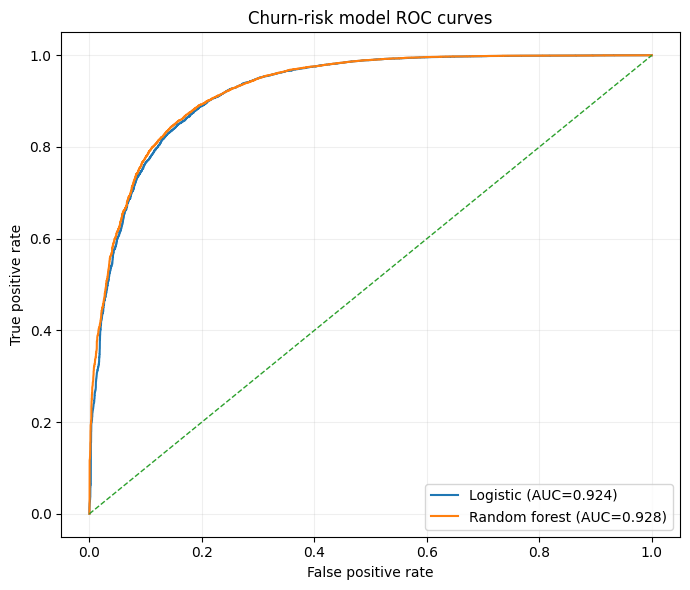

In [38]:
fpr_l, tpr_l, _ = roc_curve(y_test, p_logit)
fpr_r, tpr_r, _ = roc_curve(y_test, p_rf)

plt.figure(figsize=(7, 6))
plt.plot(fpr_l, tpr_l, label=f"Logistic (AUC={roc_auc_score(y_test, p_logit):.3f})")
plt.plot(fpr_r, tpr_r, label=f"Random forest (AUC={roc_auc_score(y_test, p_rf):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.title("Churn-risk model ROC curves")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Selected test-set model: Random Forest

Classification report at 0.50 threshold:
              precision    recall  f1-score   support

    retained       0.68      0.83      0.75      6492
     churned       0.94      0.87      0.90     19480

    accuracy                           0.86     25972
   macro avg       0.81      0.85      0.82     25972
weighted avg       0.87      0.86      0.86     25972



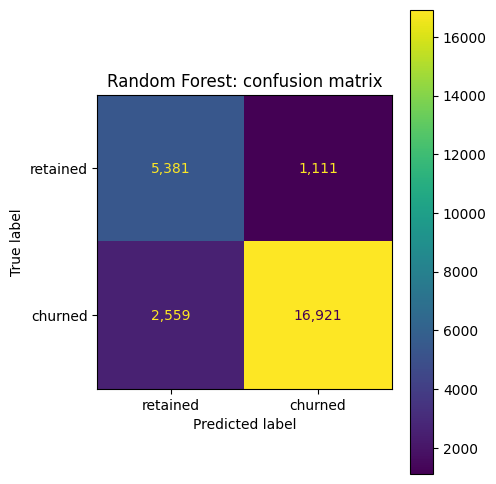

In [39]:
best_name = model_scores.sort_values("ROC AUC", ascending=False).iloc[0]["model"]
best_probs = p_logit if best_name == "Logistic Regression" else p_rf
best_pred = (best_probs >= 0.50).astype(int)

print("Selected test-set model:", best_name)
print("\nClassification report at 0.50 threshold:")
print(classification_report(y_test, best_pred, target_names=["retained", "churned"]))

cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["retained", "churned"])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, values_format=",")
plt.title(f"{best_name}: confusion matrix")
plt.tight_layout()
plt.show()

## 10. What does the interpretable model say?

The logistic coefficients provide a directional view of which early signals are associated with churn risk.

- positive coefficient → higher churn odds, holding other modeled variables constant.
- negative coefficient → lower churn odds.

These are associations, not causal effects.

In [40]:
prep_fit = logit.named_steps["prep"]
feature_names = prep_fit.get_feature_names_out()
coefs = logit.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs,
})
coef_df["odds_ratio"] = np.exp(coef_df["coefficient"])

display(coef_df.sort_values("coefficient", ascending=False).head(12))
display(coef_df.sort_values("coefficient", ascending=True).head(12))

,feature,coefficient,odds_ratio
0,cat__created_platform_Android,0.402,1.494
2,cat__country_model_BR,0.346,1.414
10,cat__country_model_RU,0.317,1.373
15,num__hours_14,0.246,1.279
11,cat__country_model_TR,0.177,1.194
7,cat__country_model_IN,0.167,1.182
9,cat__country_model_Other,0.069,1.071
8,cat__country_model_KR,0.055,1.056
18,num__revenue_14,0.033,1.034
14,num__sessions_14,0.003,1.003


,feature,coefficient,odds_ratio
13,num__active_days_14,-2.271,0.103
6,cat__country_model_GB,-0.325,0.723
16,num__avg_session_sec_14,-0.316,0.729
5,cat__country_model_FR,-0.249,0.779
1,cat__created_platform_iOS,-0.213,0.808
12,cat__country_model_US,-0.209,0.811
4,cat__country_model_DE,-0.158,0.854
17,num__purchases_14,-0.045,0.956
3,cat__country_model_CN,-0.000,1.000
14,num__sessions_14,0.003,1.003


## 11. Revenue anomaly detection

Live-service teams also need lightweight operational monitoring. We use a rolling median and median absolute deviation (MAD) to flag unusually high or low daily revenue.

This is a monitoring signal, not a diagnosis.

In [41]:
daily = activity.groupby("date").agg(
    active_players=("account_id", "nunique"),
    sessions=("session_count", "sum"),
    hours=("session_duration_sec", lambda x: x.sum() / 3600),
    purchases=("purchases", "sum"),
    revenue=("revenue_usd", "sum"),
).reset_index()

daily["rolling_median_28d"] = daily["revenue"].rolling(28, min_periods=14).median()
daily["mad_28d"] = daily["revenue"].rolling(28, min_periods=14).apply(
    lambda x: np.median(np.abs(x - np.median(x))), raw=True
)
daily["robust_z"] = (
    (daily["revenue"] - daily["rolling_median_28d"])
    / (1.4826 * daily["mad_28d"].replace(0, np.nan))
)

anomalies = daily.loc[daily["robust_z"].abs() >= 3].copy()

display(anomalies[
    ["date", "active_players", "purchases", "revenue", "rolling_median_28d", "robust_z"]
].sort_values("date").tail(15))

,date,active_players,purchases,revenue,rolling_median_28d,robust_z
29,2016-01-30,4389,56,472.300,160.980,4.183
30,2016-01-31,4412,63,"1,202.610",162.605,14.191
31,2016-02-01,4337,51,796.470,162.605,7.820
84,2016-03-25,4996,49,248.890,132.905,3.305
85,2016-03-26,5252,70,406.670,132.905,7.077
92,2016-04-02,5365,29,270.550,128.835,3.947
117,2016-04-27,4875,33,301.220,103.670,3.420
163,2016-06-12,4871,36,207.580,92.050,3.033
184,2016-07-03,5209,65,255.020,101.515,3.064
218,2016-08-06,5097,29,214.680,92.650,4.632


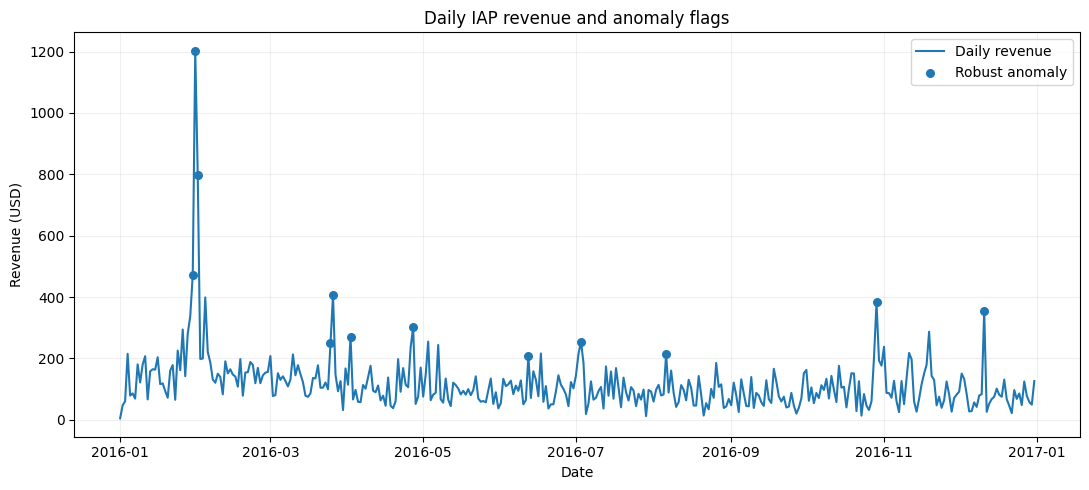

In [42]:
plt.figure(figsize=(11, 5))
plt.plot(daily["date"], daily["revenue"], linewidth=1.5, label="Daily revenue")
if len(anomalies):
    plt.scatter(anomalies["date"], anomalies["revenue"], s=30, label="Robust anomaly")
plt.title("Daily IAP revenue and anomaly flags")
plt.xlabel("Date")
plt.ylabel("Revenue (USD)")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 12. Executive readout

The analysis should end with product-facing decisions rather than only charts.

In [43]:
d1 = retention_df.loc[retention_df["metric"].eq("D1 retention"), "rate"].iloc[0]
d7 = retention_df.loc[retention_df["metric"].eq("D7 retention"), "rate"].iloc[0]
d30 = retention_df.loc[retention_df["metric"].eq("D30 retention"), "rate"].iloc[0]

largest_segment = segment_summary.sort_values("players", ascending=False).iloc[0]
largest_segment_name = largest_segment["segment"]
largest_segment_share = largest_segment["players"] / len(seg_df)
best_model_row = model_scores.sort_values("ROC AUC", ascending=False).iloc[0]

readout = f"""
### Portfolio takeaways

**1. Retention is the central lifecycle KPI.**
Exact-day retention is **D1 = {d1:.1%}**, **D7 = {d7:.1%}**, and **D30 = {d30:.1%}**.

**2. Early engagement creates useful player groups.**
The largest segment is **{largest_segment_name}**, representing **{largest_segment_share:.1%}** of players with at least one session in the first 14 days.

**3. Monetization is concentrated.**
Observed lifetime payer conversion is **{payer_rate:.1%}**, with observed IAP revenue of **${total_revenue:,.0f}** and **{payers:,}** payers.

**4. Early behavior can support churn prioritization.**
The stronger held-out model is **{best_model_row["model"]}**, with ROC AUC **{best_model_row["ROC AUC"]:.3f}** and PR AUC **{best_model_row["PR AUC"]:.3f}**.

**5. Recommended workflow.**
Use segments and churn scores to identify cohorts for lifecycle interventions, validate those interventions through controlled experiments, and monitor daily revenue anomalies as an operational signal.
"""
display(Markdown(readout))


### Portfolio takeaways

**1. Retention is the central lifecycle KPI.**
Exact-day retention is **D1 = 39.6%**, **D7 = 20.0%**, and **D30 = 10.6%**.

**2. Early engagement creates useful player groups.**
The largest segment is **One-and-done / low habit**, representing **61.6%** of players with at least one session in the first 14 days.

**3. Monetization is concentrated.**
Observed lifetime payer conversion is **1.4%**, with observed IAP revenue of **$42,495** and **1,548** payers.

**4. Early behavior can support churn prioritization.**
The stronger held-out model is **Random Forest**, with ROC AUC **0.928** and PR AUC **0.971**.

**5. Recommended workflow.**
Use segments and churn scores to identify cohorts for lifecycle interventions, validate those interventions through controlled experiments, and monitor daily revenue anomalies as an operational signal.


## 13. Limitations and next steps

**Limitations**
- This is observational data; correlations are not causal.
- No experiment assignment/treatment field is present, so no A/B-test effect is claimed.
- Daily session aggregation limits detailed funnel analysis.
- Purchase package hashes are not descriptive offer names.
- The sample is from 2016 and should not be assumed to represent a current live game.
- Exact-day retention can differ from broader retention-window definitions.

**What I would build next**
1. Add event-level telemetry for tutorial and gameplay funnels.
2. Build a weekly cohort dashboard for D1/D7/D30 and payer conversion.
3. Run a controlled experiment on onboarding/return triggers using the high-risk cohort.
4. Add package-level monetization analysis.
5. Add DAU/revenue forecasting and automated live-ops alerts.
6. Monitor churn-model calibration and drift before production use.

### Resume-ready project line

> **Mobile Game Player Lifecycle & Monetization Analytics —** Built an end-to-end Python/SQL workflow on 100K+ players to measure cohort retention, segment early player behavior, analyze IAP monetization, detect revenue anomalies, and build/evaluate a held-out churn-risk model; translated findings into actionable live-service product recommendations.

In [44]:
con.close()
print("Notebook analysis complete.")

Notebook analysis complete.
